# Training history comparison: datasets A and B (fixed N = 8)

A direct comparison of the PPO logs in `A_seed0_Nfixed8` and `B_seed0_Nfixed8`, plus reproducible equiprobable-random-action reference rollouts. The notebook compares logged training metrics with new random baseline rollouts; it does not evaluate trained checkpoints.

## Load the training logs

Load the four logged arrays directly. No row filtering or data reshaping is needed for these plots and summary statistics.

In [51]:
import sys
from pathlib import Path

import numpy as np
import json
import pandas as pd

project_root = Path.cwd().resolve()
while not (project_root / 'src').exists() and project_root != project_root.parent:
    project_root = project_root.parent
if not (project_root / 'src').exists():
    raise FileNotFoundError('Could not find the src folder.')
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from src.env import DynkinEnv

log_paths = {
    "Dataset A": project_root / "results" / "A_seed0_Nfixed8" / "train_log.npz",
    "Dataset B": project_root / "results" / "B_seed0_Nfixed8" / "train_log.npz",
}

histories = {}
for name, path in log_paths.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing training log: {path}")
    with np.load(path) as data:
        histories[name] = {key: data[key] for key in data.files}

print(f"Project root: {project_root}")
print("Loaded:", ", ".join(histories))

Project root: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds
Loaded: Dataset A, Dataset B


## Summary statistics and comparison

The table shows the first, final, and best logged values, plus the first-to-final change. Success-rate statistics ignore `NaN` entries, which occur when no episodes finish in an update.

In [52]:
import pandas as pd

summary_rows = []
for dataset, history in histories.items():
    success = history["success_rate"]
    success = success[np.isfinite(success)]
    summary_rows.append({
        "dataset": dataset,
        "updates": len(history["timesteps"]),
        "final_timesteps": int(history["timesteps"][-1]),
        "reward_first": history["reward"][0],
        "reward_final": history["reward"][-1],
        "reward_best": history["reward"].max(),
        "margin_first": history["margin"][0],
        "margin_final": history["margin"][-1],
        "margin_best": history["margin"].max(),
        "success_first": success[0] if len(success) else np.nan,
        "success_final": success[-1] if len(success) else np.nan,
        "success_best": success.max() if len(success) else np.nan,
    })

summary = pd.DataFrame(summary_rows).set_index("dataset")
display(summary.style.format({
    "reward_first": "{:+.3f}", "reward_final": "{:+.3f}", "reward_best": "{:+.3f}",
    "margin_first": "{:+.3f}", "margin_final": "{:+.3f}", "margin_best": "{:+.3f}",
    "success_first": "{:.1%}", "success_final": "{:.1%}", "success_best": "{:.1%}",
}, na_rep="—"))

for dataset, history in histories.items():
    success = history["success_rate"]
    success = success[np.isfinite(success)]
    if len(success):
        print(
            f"{dataset}: reward {history['reward'][0]:+.3f} -> {history['reward'][-1]:+.3f}; "
            f"margin {history['margin'][0]:+.3f} -> {history['margin'][-1]:+.3f}; "
            f"success rate {success[0]:.1%} -> {success[-1]:.1%}."
        )
    else:
        print(f"{dataset}: no finite success-rate values were logged.")

same_horizon = (
    summary["final_timesteps"].nunique() == 1 and summary["updates"].nunique() == 1
)
print(f"Same logged horizon and update count: {same_horizon}")

,updates,final_timesteps,reward_first,reward_final,reward_best,margin_first,margin_final,margin_best,success_first,success_final,success_best
dataset,,,,,,,,,,,
Dataset A,1953,1999872,-1.000,-1.000,-1.000,-5.766,-7.998,-5.374,0.0%,0.0%,0.0%
Dataset B,1953,1999872,-0.965,-0.990,-0.946,-3.173,-5.228,-2.794,0.0%,2.8%,14.6%


Dataset A: reward -1.000 -> -1.000; margin -5.766 -> -7.998; success rate 0.0% -> 0.0%.
Dataset B: reward -0.965 -> -0.990; margin -3.173 -> -5.228; success rate 0.0% -> 2.8%.
Same logged horizon and update count: True


## Training curves and mean-margin note

Curves are shown as logged, without smoothing. The margin calculation below reports the share of updates whose batch-mean margin is positive.

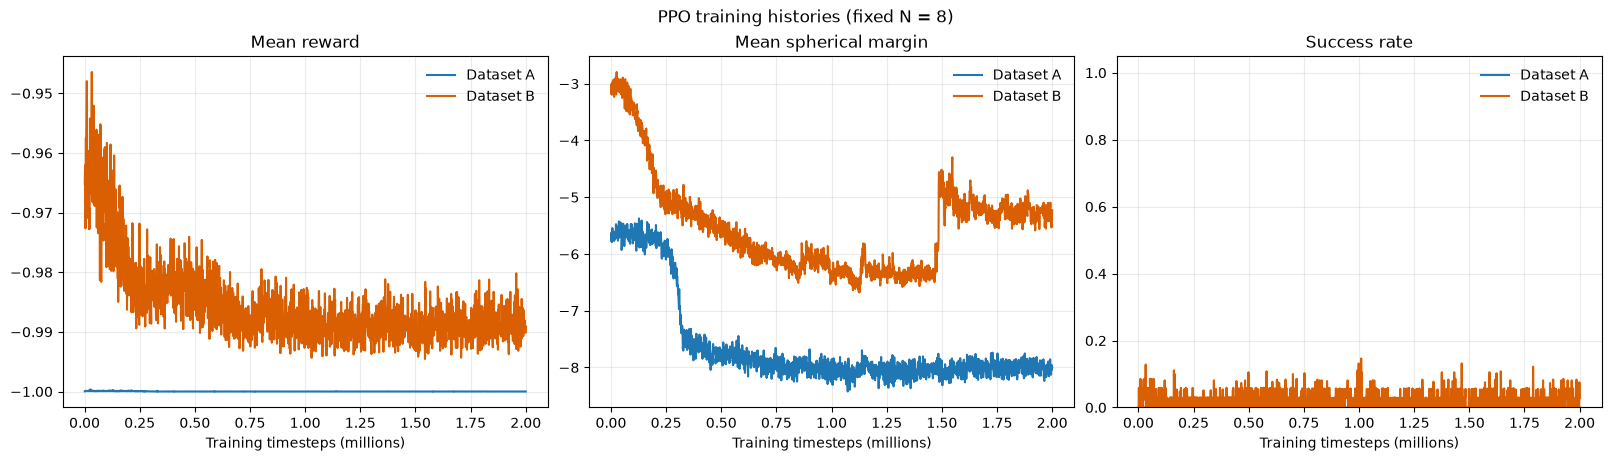

Dataset A: 0.0% of updates have a positive mean margin; overall mean = -7.627.
Dataset B: 0.0% of updates have a positive mean margin; overall mean = -5.519.
This is the fraction of updates with a positive batch-mean margin, not the fraction of individual states with positive margin. A few large positive values can outweigh many smaller negative values.


In [53]:
import matplotlib.pyplot as plt

colors = {"Dataset A": "#1f77b4", "Dataset B": "#d95f02"}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

for dataset, history in histories.items():
    x = history["timesteps"] / 1_000_000
    color = colors[dataset]
    axes[0].plot(x, history["reward"], label=dataset, color=color, linewidth=1.5)
    axes[1].plot(x, history["margin"], label=dataset, color=color, linewidth=1.5)
    axes[2].plot(x, history["success_rate"], label=dataset, color=color, linewidth=1.5)

for ax in axes:
    ax.set_xlabel("Training timesteps (millions)")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)

axes[0].set_title("Mean reward")
axes[1].set_title("Mean spherical margin")
axes[2].set_title("Success rate")
axes[2].set_ylim(0, 1.05)
fig.suptitle("PPO training histories (fixed N = 8)")
plt.show()

for dataset, history in histories.items():
    margin = history["margin"]
    positive_fraction = np.mean(margin > 0)
    print(f"{dataset}: {positive_fraction:.1%} of updates have a positive mean margin; "
          f"overall mean = {margin.mean():+.3f}.")

print("This is the fraction of updates with a positive batch-mean margin, "
      "not the fraction of individual states with positive margin. A few large "
      "positive values can outweigh many smaller negative values.")

## Equiprobable random-action baseline

Generate 1,000 independent random-action episodes for each dataset at fixed N = 8. Actions are sampled uniformly from the environment's 112-action space. Raw transition margins and per-episode outcomes are saved under `results/`; this cell generates and saves them each time the notebook is run. The random baseline curves below are overall mean-margin references, not time-varying training histories.

In [54]:
N_EPISODES = 1_000
MAX_EPISODE_STEPS = 30
BASELINE_SEED = 2026

results_dir = project_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)
baseline_rows = []
baseline_episode_summaries = []

for dataset_index, dataset_code in enumerate(("A", "B")):
    env_seed = BASELINE_SEED + dataset_index
    action_seed = BASELINE_SEED + 100 + dataset_index
    env = DynkinEnv(
        n=8,
        max_steps=MAX_EPISODE_STEPS,
        dataset=dataset_code,
        seed=env_seed,
    )
    action_rng = np.random.default_rng(action_seed)

    for episode in range(N_EPISODES):
        env.reset()
        episode_rows = []
        episode_success = False

        for step in range(1, MAX_EPISODE_STEPS + 1):
            action = int(action_rng.integers(0, env.action_dim))
            _, _, terminated, truncated, info = env.step(action)
            episode_rows.append({
                "dataset": dataset_code,
                "episode": episode,
                "step": step,
                "action": action,
                "margin": info.margin,
            })
            if terminated or truncated:
                episode_success = bool(info.success)
                break

        for row in episode_rows:
            row["episode_success"] = episode_success
            baseline_rows.append(row)
        baseline_episode_summaries.append({
            "dataset": dataset_code,
            "episode": episode,
            "steps": len(episode_rows),
            "success": episode_success,
        })

baseline_data = pd.DataFrame(baseline_rows)
baseline_episodes = pd.DataFrame(baseline_episode_summaries)

baseline_csv_path = results_dir / "random_baseline_Nfixed8.csv"
baseline_metadata_path = results_dir / "random_baseline_Nfixed8.json"
baseline_data.to_csv(baseline_csv_path, index=False)

baseline_metadata = {
    "n": 8,
    "max_episode_steps": MAX_EPISODE_STEPS,
    "episodes_per_dataset": N_EPISODES,
    "datasets": ["A", "B"],
    "action_dim": 112,
    "action_sampling": "uniform integer action in [0, action_dim)",
    "env_seeds": {"A": BASELINE_SEED, "B": BASELINE_SEED + 1},
    "action_rng_seeds": {"A": BASELINE_SEED + 100, "B": BASELINE_SEED + 101},
    "margin": "raw per-transition spherical margin from StepInfo.margin",
    "success": "episode_success is repeated on each transition row for its episode",
}
baseline_metadata_path.write_text(json.dumps(baseline_metadata, indent=2), encoding="utf-8")

baseline_summary = baseline_data.groupby("dataset").agg(
    transitions=("margin", "size"),
    mean_margin=("margin", "mean"),
    max_margin=("margin", "max"),
)
baseline_episode_summary = baseline_episodes.groupby("dataset").agg(
    episodes=("episode", "size"),
    successes=("success", "sum"),
    success_rate=("success", "mean"),
)
baseline_summary = baseline_summary.join(baseline_episode_summary)
display(baseline_summary.style.format({
    "mean_margin": "{:+.3f}",
    "max_margin": "{:+.3f}",
    "success_rate": "{:.1%}",
}))
print(f"Saved transition records: {baseline_csv_path}")
print(f"Saved run configuration: {baseline_metadata_path}")

,transitions,mean_margin,max_margin,episodes,successes,success_rate
dataset,,,,,,
A,30000,-5.524,-2.536,1000,0,0.0%
B,29541,-2.925,+0.586,1000,16,1.6%


Saved transition records: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\results\random_baseline_Nfixed8.csv
Saved run configuration: D:\Programacao\Codigos\AI-testing-in-Flag-Manifolds\results\random_baseline_Nfixed8.json


## Smoothed PPO margins and random-action references

PPO margins are smoothed with a trailing moving average (50 updates by default). Each random baseline is shown as its overall per-transition mean across the full training timestep range; the horizontal lines are constant references, not training trajectories. The shared x-axis is actual environment timesteps.

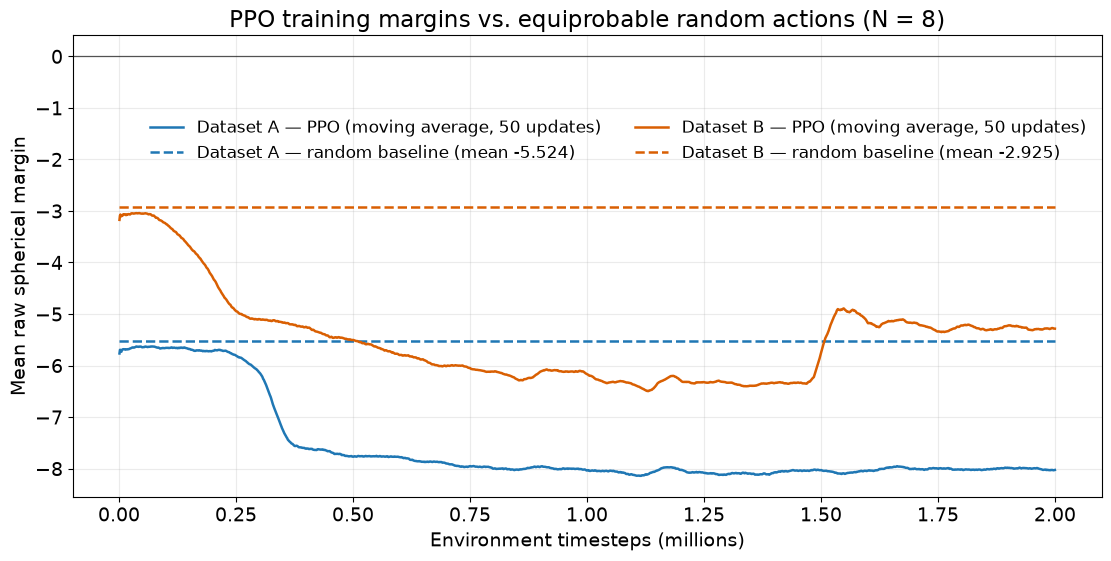

PPO smoothing: trailing window of 50 updates; random references: overall mean across saved baseline transitions.


In [55]:
MOVING_AVERAGE_UPDATES = 50

with plt.rc_context({'font.size': 14}):
    fig, ax = plt.subplots(figsize=(11, 5.5), constrained_layout=True)
    random_means = baseline_data.groupby("dataset")["margin"].mean()

    for dataset_name, dataset_code in (("Dataset A", "A"), ("Dataset B", "B")):
        history = histories[dataset_name]
        timesteps = history["timesteps"]
        margin = pd.Series(history["margin"])
        smoothed_margin = margin.rolling(
            window=MOVING_AVERAGE_UPDATES,
            min_periods=1,
        ).mean()
        color = colors[dataset_name]

        ax.plot(
            timesteps / 1_000_000,
            smoothed_margin,
            color=color,
            linewidth=1.8,
            label=f"{dataset_name} — PPO (moving average, {MOVING_AVERAGE_UPDATES} updates)",
        )
        baseline_mean = float(random_means[dataset_code])
        ax.plot(
            [timesteps[0] / 1_000_000, timesteps[-1] / 1_000_000],
            [baseline_mean, baseline_mean],
            color=color,
            linestyle="--",
            linewidth=1.8,
            label=f"{dataset_name} — random baseline (mean {baseline_mean:+.3f})",
        )

    ax.axhline(0, color="black", linewidth=0.9, alpha=0.65)
    ax.set_xlabel("Environment timesteps (millions)")
    ax.set_ylabel("Mean raw spherical margin")
    ax.set_title("PPO training margins vs. equiprobable random actions (N = 8)")
    ax.grid(alpha=0.25)
    ax.legend(frameon=False, ncol=2, fontsize=12, loc="upper right", bbox_to_anchor=(1.0, 0.85))
    plt.show()

print(
    f"PPO smoothing: trailing window of {MOVING_AVERAGE_UPDATES} updates; "
    "random references: overall mean across saved baseline transitions."
)